# Task 8 — M3: biological network / module knowledge

**Question.** Does knowing that certain noisy features belong together in a biological module improve
**prediction** or **interpretability**, compared with treating the raw proxies independently and with
an equally complex but **biologically incorrect** grouping?

**The knowledge graph is synthetic.** It is not real RNA biology, is not derived from KEGG or Reactome,
and no biological validation is claimed. A module-level coefficient is a **predictive association**
under a fitted model, not a causal claim and not a statement about real regulatory or pathway
biology.

## The one thing the prior supplies

**Which observed variables belong together. Nothing else.** No weights (scores are unweighted means),
no learned parameters, no labels, no latent states, no known noise variances, no ordering. Membership
is imported from `src/knowledge_graph.py`, which is the **single authoritative source** — it is not
restated in the modelling module, so a "network-informed" model cannot silently drift onto a
different grouping from the documented one.

## Replacement, not appending — the primary design

The four raw proxies are **replaced** by two module scores, taking the representation from 12 columns
to 10:

```
regulatory_module_score = mean(reg_feature_1, reg_feature_2)
pathway_module_score    = mean(pathway_feature_1, pathway_feature_2)
```

The incorrect control replaces **exactly the same four columns** with two incorrect-grouping scores,
giving the identical 12 → 10 reduction. All other observable features are unchanged, and **no FRET
prior, structural prior, or relevance weighting is added** — this task isolates the network prior.

Why replacement rather than appending: if the four raw columns were kept alongside the scores, a
model could simply ignore the scores, and a null result would be uninterpretable — we would not know
whether the grouping failed or whether the model sidestepped it. Replacement forces the grouping to
carry the information, which makes the comparison informative either way. A raw-plus-means
condition appears once as a clearly secondary diagnostic.

## The incorrect grouping

```
incorrect_module_1 = mean(reg_feature_1,  pathway_feature_1)
incorrect_module_2 = mean(reg_feature_2,  pathway_feature_2)
```

Identical module count (2), module sizes (2 each), and aggregation form. Fixed in `knowledge_graph`
before any evaluation and chosen **without labels or performance**, by crossing the correct module
boundaries. It differs from the correct grouping **only in membership**.

## Headline, stated up front

The correct grouping **does not improve prediction** and, in the logistic model, is **worse than the
biologically incorrect grouping** — while the diagnostic in Section 6 shows the correct module score
recovers the hidden module state **more faithfully** than any alternative. That dissociation is the
central result of this task, and it is reported as found.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "knowledge_graph.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import knowledge_graph as KG
import network_knowledge as N
import prototype_model as P
import validation_checks as V

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()      # model-facing only
m3 = json.loads((ROOT / "results" / "network_knowledge_cv.json").read_text())
print("candidates:", candidates.shape, "| base features:", len(V.FEATURE_COLUMNS))
print("fingerprint:", m3["protocol"]["fold_fingerprint"],
      "| verified identical:", m3["protocol"]["folds_verified_identical"])
print("primary design:", m3["protocol"]["primary_design"])
print("grouping fixed before evaluation:", m3["protocol"]["grouping_fixed_before_evaluation"])
print("FRET prior:", m3["protocol"]["no_fret_prior_used"],
      "| structural prior:", m3["protocol"]["no_structural_prior_used"],
      "| relevance weights:", m3["protocol"]["no_relevance_weighting_used"],
      "| latent truth:", m3["protocol"]["latent_truth_used"])

candidates: (800, 14) | base features: 12
fingerprint: 9b587aa3d19a36f7 | verified identical: True
primary design: replacement (12 -> 10 columns), identical for correct and incorrect
grouping fixed before evaluation: True
FRET prior: True | structural prior: True | relevance weights: True | latent truth: False


## 1. The knowledge graph

A small three-level hierarchy over **observed variables only**. Deliberately absent: latent states,
modules without observed members, and any edge among proxies. The two regulatory proxies are
*members of one module*, not neighbours of each other — module membership is the only relation
asserted, and that is the entire prior under test.

`PROJECT_BRIEF` §6 suggests four modules (A structural stability, B FRET-supported geometry, C
regulatory interaction, D weak/noisy biology). Only the regulatory and pathway modules have observed
proxies in this dataset, so only those two are nodes. The other two are left out rather than
represented by empty nodes, since an empty module node would imply knowledge that cannot be acted on.

In [2]:
KG.validate_groupings()   # fails loudly if the control stops being complexity-matched
g = KG.build_knowledge_graph()
gi = KG.build_incorrect_grouping_graph()

print(f"nodes={g.number_of_nodes()}  edges={g.number_of_edges()}")
print("node kinds:", {n: g.nodes[n]["kind"] for n in sorted(g.nodes)})
print("\nedges:", [(a, b, d["relation"]) for a, b, d in g.edges(data=True)])
print("\nfeature -> module:", json.dumps(KG.FEATURE_TO_MODULE, indent=2))
print("incorrect        :", json.dumps(KG.INCORRECT_FEATURE_TO_MODULE, indent=2))
print("module score names:", KG.module_score_names())
print("contains latent states:", m3["knowledge_graph"]["contains_latent_states"])

nodes=7  edges=6
node kinds: {'pathway_feature_1': 'feature', 'pathway_feature_2': 'feature', 'pathway_level': 'pathway_level', 'pathway_module': 'module', 'reg_feature_1': 'feature', 'reg_feature_2': 'feature', 'regulatory_module': 'module'}

edges: [('reg_feature_1', 'regulatory_module', 'member_of'), ('regulatory_module', 'pathway_level', 'part_of'), ('reg_feature_2', 'regulatory_module', 'member_of'), ('pathway_feature_1', 'pathway_module', 'member_of'), ('pathway_module', 'pathway_level', 'part_of'), ('pathway_feature_2', 'pathway_module', 'member_of')]

feature -> module: {
  "reg_feature_1": "regulatory_module",
  "reg_feature_2": "regulatory_module",
  "pathway_feature_1": "pathway_module",
  "pathway_feature_2": "pathway_module"
}
incorrect        : {
  "reg_feature_1": "incorrect_module_1",
  "pathway_feature_1": "incorrect_module_1",
  "reg_feature_2": "incorrect_module_2",
  "pathway_feature_2": "incorrect_module_2"
}
module score names: {'regulatory_module': 'regulatory_mo

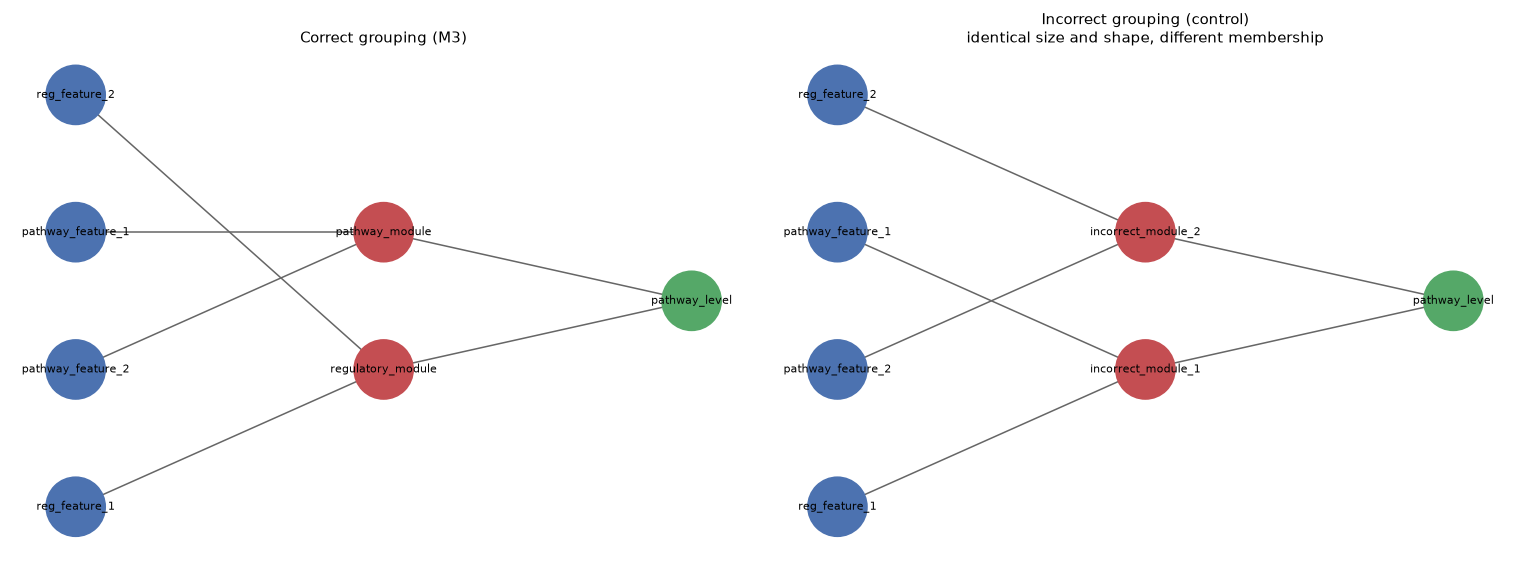

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, (graph, title) in zip(axes, [
    (g, "Correct grouping (M3)"),
    (gi, "Incorrect grouping (control)\nidentical size and shape, different membership"),
]):
    pos = nx.multipartite_layout(graph, subset_key="kind")
    colours = {"feature": "#4C72B0", "module": "#C44E52", "pathway_level": "#55A868"}
    nx.draw_networkx_nodes(graph, pos, ax=ax,
                           node_color=[colours[graph.nodes[n]["kind"]] for n in graph.nodes],
                           node_size=1500)
    nx.draw_networkx_edges(graph, pos, ax=ax, arrows=False, edge_color="0.4")
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=7)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.show()

In [4]:
members_c = KG.module_members(KG.FEATURE_TO_MODULE)
members_i = KG.module_members(KG.INCORRECT_FEATURE_TO_MODULE)
rows = [{"grouping": "correct", "module": m, "members": ", ".join(f)} for m, f in members_c.items()]
rows += [{"grouping": "incorrect (control)", "module": m, "members": ", ".join(f)}
         for m, f in members_i.items()]
print("complexity matching:")
print(f"  module count   correct={len(members_c)}  incorrect={len(members_i)}")
print(f"  module sizes   correct={sorted(len(v) for v in members_c.values())}  "
      f"incorrect={sorted(len(v) for v in members_i.values())}")
print(f"  columns replaced  correct={len(KG.AGGREGATED_FEATURES)}  incorrect={len(KG.AGGREGATED_FEATURES)}")
print(f"  groupings differ  {members_c != members_i}")
print()
pd.DataFrame(rows)

complexity matching:
  module count   correct=2  incorrect=2
  module sizes   correct=[2, 2]  incorrect=[2, 2]
  columns replaced  correct=4  incorrect=4
  groupings differ  True



,grouping,module,members
0,correct,regulatory_module,"reg_feature_1, reg_feature_2"
1,correct,pathway_module,"pathway_feature_1, pathway_feature_2"
2,incorrect (control),incorrect_module_1,"reg_feature_1, pathway_feature_1"
3,incorrect (control),incorrect_module_2,"reg_feature_2, pathway_feature_2"


`validate_groupings()` asserts all of this at run time: same module count, same sizes, exactly the
same four columns replaced, and a control that genuinely differs from the correct grouping. If the
control ever stopped being complexity-matched, the comparison would stop testing what it claims to
and the run would fail rather than quietly produce a meaningless number.

## 2. Protocol

Identical folds (`9b587aa3d19a36f7`), asserted in code. Scaling refit inside every training fold. Module
scores are equal-weight means computed per row from observable features only — no labels, no latent
state, no fitted statistic, so they are identical for training and held-out rows. Nothing tuned, and
no regrouping after seeing results.

In [5]:
rows = [{"setting": k, "value": str(v)[:130]}
        for k, v in m3["protocol"].items() if k not in ("base_features", "aggregated_features")]
pd.DataFrame(rows)

,setting,value
0,name,stratified 5-fold cross-validation (shared wit...
1,role,PRIMARY
2,n_splits,5
3,random_state,0
4,fold_fingerprint,9b587aa3d19a36f7
5,folds_verified_identical,True
6,preprocessing,StandardScaler refit within each training fold...
7,primary_design,"replacement (12 -> 10 columns), identical for ..."
8,module_scores,{'regulatory_module': 'regulatory_module_score...
9,incorrect_grouping_scores,{'incorrect_module_1': 'incorrect_module_1_sco...


In [6]:
for name, desc in m3["conditions"].items():
    print(f"{N.SHORT[name]:6s} {name:38s} {desc}")

LR0    LR0_logistic_raw                       raw Logistic Regression (reference)
LR3    LR3_logistic_module_replacement        LR0 with correct module REPLACEMENT (M3, main)
LR3c   LR3c_logistic_incorrect_grouping       LR0 with incorrect-grouping replacement (control)
LR3a   LR3a_logistic_module_appended          SECONDARY DIAGNOSTIC: raw proxies + module scores
P0     P0_plain_prototype                     plain prototype (reference)
P3     P3_prototype_module_replacement        P0 with correct module REPLACEMENT (M3, main)
P3c    P3c_prototype_incorrect_grouping       P0 with incorrect-grouping replacement (control)
HGB0   HGB0_hist_gradient_boosting            generic nonlinear boosting (context only)


## 3. Results

In [7]:
MET = cv_protocol.PRIMARY_METRICS
ORDER = ["LR0_logistic_raw", "LR3_logistic_module_replacement", "LR3c_logistic_incorrect_grouping",
         "LR3a_logistic_module_appended", "HGB0_hist_gradient_boosting",
         "P0_plain_prototype", "P3_prototype_module_replacement", "P3c_prototype_incorrect_grouping"]
ROLE = {"LR0_logistic_raw": "reference", "LR3_logistic_module_replacement": "M3 (main)",
        "LR3c_logistic_incorrect_grouping": "control", "LR3a_logistic_module_appended": "2nd diagnostic",
        "HGB0_hist_gradient_boosting": "context", "P0_plain_prototype": "reference",
        "P3_prototype_module_replacement": "M3 (main)", "P3c_prototype_incorrect_grouping": "control"}

rows = []
for name in ORDER:
    st = m3["summary_mean_std"][name]
    row = {"condition": N.SHORT[name], "role": ROLE[name]}
    row.update({m: f"{st[m]['mean']:.4f} ± {st[m]['std']:.4f}" for m in MET})
    rows.append(row)
pd.DataFrame(rows)

,condition,role,accuracy,balanced_accuracy,auroc,f1,brier
0,LR0,reference,0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
1,LR3,M3 (main),0.7625 ± 0.0177,0.7479 ± 0.0168,0.8257 ± 0.0185,0.6956 ± 0.0207,0.1649 ± 0.0092
2,LR3c,control,0.7612 ± 0.0204,0.7444 ± 0.0249,0.8311 ± 0.0155,0.6885 ± 0.0349,0.1635 ± 0.0091
3,LR3a,2nd diagnostic,0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
4,HGB0,context,0.7188 ± 0.0225,0.7027 ± 0.0224,0.8054 ± 0.0233,0.6399 ± 0.0281,0.1824 ± 0.0137
5,P0,reference,0.7512 ± 0.0255,0.7519 ± 0.0244,0.8276 ± 0.0168,0.7104 ± 0.0279,0.1793 ± 0.0049
6,P3,M3 (main),0.7525 ± 0.0210,0.7550 ± 0.0209,0.8245 ± 0.0159,0.7146 ± 0.0242,0.1863 ± 0.0038
7,P3c,control,0.7512 ± 0.0156,0.7524 ± 0.0169,0.8250 ± 0.0163,0.7110 ± 0.0209,0.1810 ± 0.0047


In [8]:
for name in ORDER:
    print(f"{N.SHORT[name]:6s} ({ROLE[name]})")
    for f in m3["per_fold"][name]:
        cm = f["confusion_matrix"]
        assert np.isclose(f["accuracy"], (cm["tn"] + cm["tp"]) / cm["n"]), f"{name} fold {f['fold']}"
        print(f"  fold {f['fold']}  n={cm['n']:3d} cm={str(cm['counts']):<18} "
              f"acc={f['accuracy']:.4f} auroc={f['auroc']:.4f} f1={f['f1']:.4f} brier={f['brier']:.4f}")
    print()
print("every fold of every condition reconciles accuracy with its own confusion matrix")

LR0    (reference)
  fold 0  n=160 cm=[[77, 19], [17, 47]] acc=0.7750 auroc=0.8122 f1=0.7231 brier=0.1725
  fold 1  n=160 cm=[[77, 19], [24, 40]] acc=0.7312 auroc=0.8255 f1=0.6504 brier=0.1682
  fold 2  n=160 cm=[[79, 16], [20, 45]] acc=0.7750 auroc=0.8483 f1=0.7143 brier=0.1523
  fold 3  n=160 cm=[[81, 14], [22, 43]] acc=0.7750 auroc=0.8419 f1=0.7049 brier=0.1571
  fold 4  n=160 cm=[[82, 13], [28, 37]] acc=0.7438 auroc=0.8172 f1=0.6435 brier=0.1715

LR3    (M3 (main))
  fold 0  n=160 cm=[[77, 19], [21, 43]] acc=0.7500 auroc=0.8101 f1=0.6825 brier=0.1732
  fold 1  n=160 cm=[[76, 20], [22, 42]] acc=0.7375 auroc=0.8211 f1=0.6667 brier=0.1679
  fold 2  n=160 cm=[[78, 17], [19, 46]] acc=0.7750 auroc=0.8406 f1=0.7188 brier=0.1555
  fold 3  n=160 cm=[[81, 14], [22, 43]] acc=0.7750 auroc=0.8492 f1=0.7049 brier=0.1546
  fold 4  n=160 cm=[[81, 14], [22, 43]] acc=0.7750 auroc=0.8074 f1=0.7049 brier=0.1733

LR3c   (control)
  fold 0  n=160 cm=[[77, 19], [17, 47]] acc=0.7750 auroc=0.8114 f1=0.7231

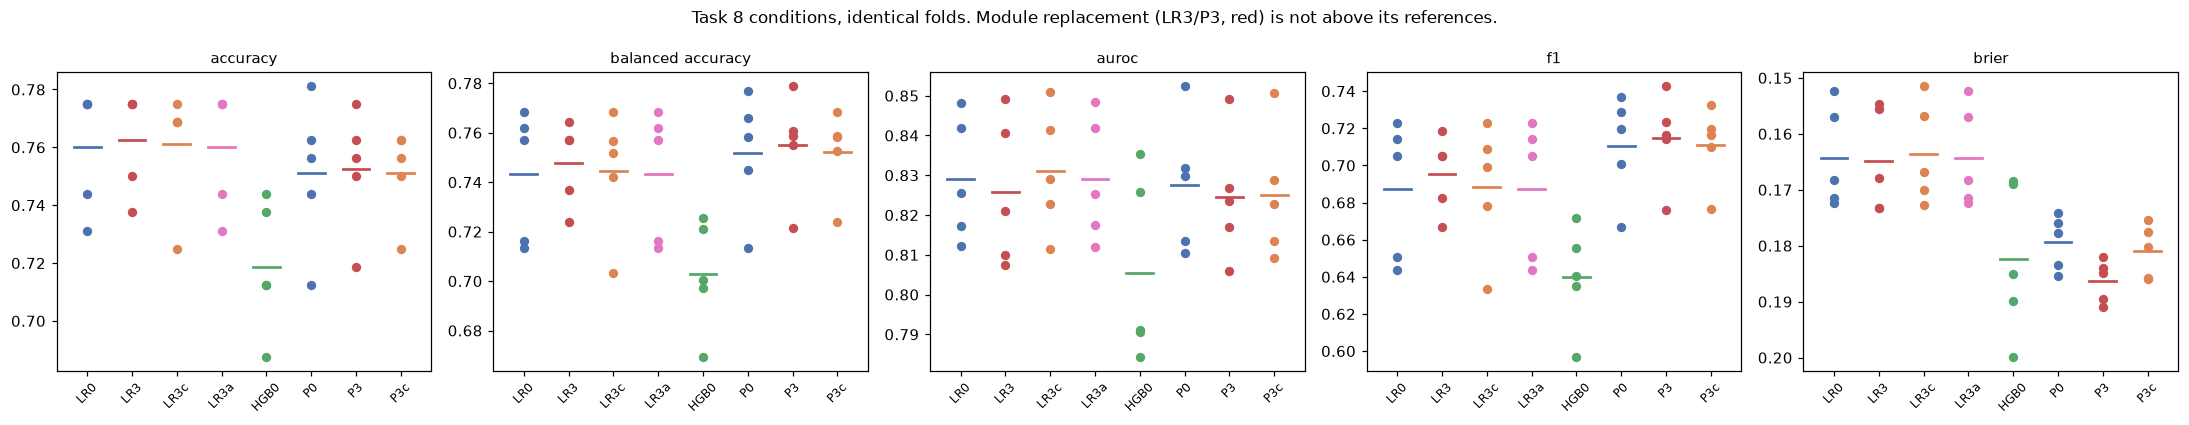

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.9))
colours = {"LR0": "#4C72B0", "LR3": "#C44E52", "LR3c": "#DD8452", "LR3a": "#E377C2",
           "P0": "#4C72B0", "P3": "#C44E52", "P3c": "#DD8452", "HGB0": "#55A868"}
for ax, metric in zip(axes, MET):
    for i, name in enumerate(ORDER):
        vals = [f[metric] for f in m3["per_fold"][name]]
        ax.scatter([i + 1] * len(vals), vals, color=colours[N.SHORT[name]], s=26, zorder=3)
        ax.plot([i + 0.7, i + 1.3], [np.mean(vals)] * 2, color=colours[N.SHORT[name]], lw=1.8)
    ax.set_xticks(range(1, 9))
    ax.set_xticklabels([N.SHORT[n] for n in ORDER], fontsize=8, rotation=45)
    ax.set_title(metric.replace("_", " "), fontsize=10)
    if metric == "brier":
        ax.invert_yaxis()
fig.suptitle("Task 8 conditions, identical folds. Module replacement (LR3/P3, red) is not above its references.",
             fontsize=11)
plt.show()

## 4. Fold-wise comparisons

In [10]:
for group, pairs in m3["comparison"].items():
    print(f"=== {group.upper()} ===")
    for label, rows in pairs.items():
        print(f"{label:14s} (positive = first-named better; for brier, positive = WORSE)")
        print(f"  {'metric':19s} {'new':>8s} {'ref':>8s} {'mean diff':>10s}  per-fold differences")
        for row in rows:
            diffs = " ".join(f"{d:+.4f}" for d in row["per_fold_difference"])
            print(f"  {row['metric']:19s} {row['new_mean']:8.4f} {row['reference_mean']:8.4f} "
                  f"{row['mean_difference']:+10.4f}  {diffs}")
        print()

=== PRIMARY ===
LR3_vs_LR0     (positive = first-named better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7625   0.7600    +0.0025  -0.0250 +0.0063 +0.0000 +0.0000 +0.0312
  balanced_accuracy     0.7479   0.7434    +0.0045  -0.0312 +0.0104 +0.0024 +0.0000 +0.0409
  auroc                 0.8257   0.8290    -0.0033  -0.0021 -0.0044 -0.0076 +0.0073 -0.0097
  f1                    0.6956   0.6872    +0.0083  -0.0405 +0.0163 +0.0045 +0.0000 +0.0614
  brier                 0.1649   0.1643    +0.0006  +0.0007 -0.0003 +0.0033 -0.0024 +0.0019

LR3_vs_LR3c    (positive = first-named better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7625   0.7612    +0.0012  -0.0250 +0.0125 +0.0062 +0.0062 +0.0062
  balanced_accuracy     0.7479   0.7444    +0.0035  -0.0312 +0.0208 +0.0077 +0.0053 +0.0150
  auroc                 0.8257   0.8311  

In [11]:
def C(group, label):
    return {r["metric"]: r for r in m3["comparison"][group][label]}

pairs = [("LR3 vs LR0", C("primary", "LR3_vs_LR0")),
         ("LR3 vs LR3c", C("primary", "LR3_vs_LR3c")),
         ("P3 vs P0", C("primary", "P3_vs_P0")),
         ("P3 vs P3c", C("primary", "P3_vs_P3c")),
         ("LR3 vs HGB0 (context)", C("context", "LR3_vs_HGB0")),
         ("P3 vs HGB0 (context)", C("context", "P3_vs_HGB0"))]

rows = []
for label, c in pairs:
    row = {"comparison": label}
    for m in MET:
        row[m] = f"{c[m]['mean_difference']:+.4f} ({c[m]['n_folds_new_better']}/5)"
    rows.append(row)
pd.DataFrame(rows)

,comparison,accuracy,balanced_accuracy,auroc,f1,brier
0,LR3 vs LR0,+0.0025 (2/5),+0.0045 (3/5),-0.0033 (1/5),+0.0083 (3/5),+0.0006 (3/5)
1,LR3 vs LR3c,+0.0012 (4/5),+0.0035 (4/5),-0.0054 (1/5),+0.0071 (4/5),+0.0014 (4/5)
2,P3 vs P0,+0.0012 (3/5),+0.0031 (4/5),-0.0031 (1/5),+0.0042 (4/5),+0.0069 (5/5)
3,P3 vs P3c,+0.0013 (1/5),+0.0026 (3/5),-0.0006 (2/5),+0.0037 (3/5),+0.0053 (5/5)
4,LR3 vs HGB0 (context),+0.0437 (5/5),+0.0452 (5/5),+0.0203 (4/5),+0.0556 (5/5),-0.0175 (1/5)
5,P3 vs HGB0 (context),+0.0337 (5/5),+0.0523 (5/5),+0.0191 (4/5),+0.0747 (5/5),+0.0039 (3/5)


### The four primary answers, plainly

| comparison | AUROC | accuracy | F1 | Brier | folds better (AUROC) |
|---|---|---|---|---|---|
| **LR3 − LR0** | **−0.0033** | +0.0025 | +0.0084 | +0.0006 (worse) | 1/5 |
| **LR3 − LR3c** | **−0.0054** | +0.0013 | +0.0071 | +0.0014 (worse) | 1/5 |
| **P3 − P0** | **−0.0031** | +0.0013 | +0.0042 | +0.0070 (worse) | 1/5 |
| **P3 − P3c** | **−0.0006** | +0.0013 | +0.0036 | +0.0053 (worse) | 2/5 |

**Does correct module aggregation improve LR over LR0? No.** AUROC **−0.0033**, positive in only
1 of 5 folds (per fold −0.0069, −0.0031, −0.0019, −0.0023, −0.0018). Accuracy (+0.0025) and F1
(+0.0084) improve slightly, but Brier gets worse and the headline metric moves consistently the wrong
way.

**Does it improve the prototype model over P0? No.** AUROC **−0.0031**, 1 of 5 folds. Accuracy and F1
improve marginally; **Brier degrades substantially (+0.0070)**, the largest single degradation seen
anywhere in this project.

**Does the correct grouping beat the equally complex incorrect grouping? No — it is worse.**

| | AUROC | folds better |
|---|---|---|
| **LR3 − LR3c** (correct vs incorrect, logistic) | **−0.0054** | 1/5 |
| **P3 − P3c** (correct vs incorrect, prototype) | −0.0006 | 2/5 |

The logistic result is the sharp one: **the biologically correct grouping is worse than a grouping
that is deliberately wrong**, worse in 4 of 5 folds, by a margin roughly the size of the entire
effect. This is not a null result with noise attached — the control beat the treatment.

**Secondary diagnostic.** Appending module scores to the raw proxies (LR3a) reproduces LR0 almost
exactly (AUROC difference −0.0000). As predicted in Section 0, the model simply ignores the added
columns and keeps the raw proxies — which is exactly why replacement is the informative design.

**Context only.** LR3 − HGB0 = +0.0203 and P3 − HGB0 = +0.0191, both beating generic boosting. As
the brief instructs, this is **not** treated as evidence for the network prior: HGB0 was already
0.024 behind LR0 in Task 3.

### Why a correct grouping can lose to an incorrect one

This is the surprising part, and it is worth being precise rather than reaching for the nearest
available story.

**Both aggregations remove information.** Each replaces two variables with one, and each of the four
proxies carries proxy-specific variation. The two designs are not "one aggregates and one does not" —
they are *different* aggregations, both lossy.

**The incorrect grouping mixes two different hidden states.** `mean(reg_feature_1, pathway_feature_1)`
averages a regulatory-state proxy with a pathway-state proxy. The diagnostic in Section 6 shows these
components are only ~0.25 correlated, so this score is a genuinely mixed quantity.

**But the label does not depend on one module state alone.** It is a sum of contributions from both
modules plus structural and FRET terms. A score that blurs the two modules together is still
monotone in *some* combination of them, and a logistic model with a remaining ten columns can
reconstruct the rest. The information destroyed by the correct grouping — the difference between
`reg_feature_1` and `reg_feature_2` — is apparently more useful to the model than the ability to
recover `a_C` exactly.

So the two aggregations destroy different information, and on this dataset **the wrong one happens
to destroy the less useful information**. That is a statement about this dataset and this label rule,
not a general principle, and it is stated here as an interpretation of the measurements rather than
as a demonstrated mechanism.

## 5. Interpretability

> The module grouping was **supplied by prior knowledge** from the knowledge graph. The model **did
> not discover** module membership — it was handed a representation in which the grouping was already
> done. Every quantity below is a **predictive association**, not a causal claim.

In [12]:
il = m3["interpretability"]
print(il["note"], "\n")
coefs = pd.DataFrame(il["lr3_standardized_coefficients"])
module_rows = coefs[coefs["feature"].str.contains("module")]
print("LR3 standardized coefficients for the two module scores:")
print(module_rows.to_string(index=False))
print("\ntop six coefficients overall, for context:")
print(coefs.head(6).to_string(index=False))

Coefficients and separations are PREDICTIVE associations from descriptive fits, not causal claims. The module grouping was SUPPLIED by prior knowledge from the knowledge graph; the model did not discover membership. 

LR3 standardized coefficients for the two module scores:
                feature  coefficient  abs_coefficient
   pathway_module_score     0.700847         0.700847
regulatory_module_score     0.623978         0.623978

top six coefficients overall, for context:
                feature  coefficient  abs_coefficient
   pathway_module_score     0.700847         0.700847
regulatory_module_score     0.623978         0.623978
 structural_consistency     0.614053         0.614053
             fret_error    -0.410723         0.410723
             stem_count     0.209620         0.209620
            free_energy    -0.168840         0.168840


In [13]:
sep_correct = il["p3_prototype_separation_correct"]
sep_raw = il["p0_prototype_separation_raw_proxies"]
rows = []
for module, features in KG.module_members(KG.FEATURE_TO_MODULE).items():
    score_name = KG.module_score_names()[module]
    rows.append({
        "module": module,
        "member 1": features[0], "member 2": features[1],
        f"P0 sep({features[0]})": sep_raw[features[0]],
        f"P0 sep({features[1]})": sep_raw[features[1]],
        "mean of the two": np.mean([sep_raw[features[0]], sep_raw[features[1]]]),
        f"P3 sep({score_name})": sep_correct[score_name],
    })
pd.DataFrame(rows).round(4)

,module,member 1,member 2,P0 sep(reg_feature_1),P0 sep(reg_feature_2),mean of the two,P3 sep(regulatory_module_score),P0 sep(pathway_feature_1),P0 sep(pathway_feature_2),P3 sep(pathway_module_score)
0,regulatory_module,reg_feature_1,reg_feature_2,0.7897,0.6596,0.7246,0.7977,NaN,NaN,NaN
1,pathway_module,pathway_feature_1,pathway_feature_2,NaN,NaN,0.7551,NaN,0.8183,0.6918,0.8297


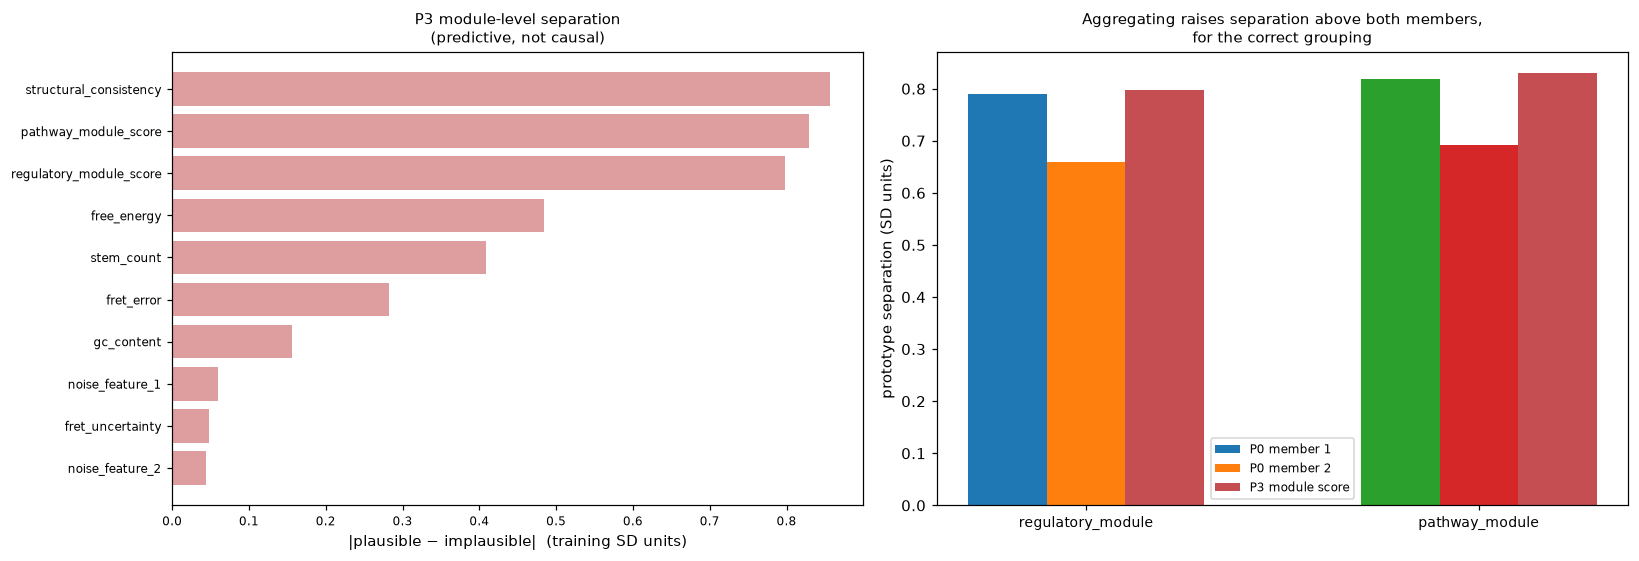

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
seps = pd.Series(sep_correct).sort_values()
ax.barh(seps.index, seps.values, color="#C44E52", alpha=0.55,
        label="P3: prototype separation (module representation)")
ax.set_xlabel("|plausible − implausible|  (training SD units)")
ax.set_title("P3 module-level separation\n(predictive, not causal)", fontsize=10)
ax.tick_params(labelsize=8)

ax = axes[1]
x = np.arange(len(rows))
for i, r in enumerate(rows):
    ax.bar(i - 0.2, r[f"P0 sep({r['member 1']})"], 0.2, label="P0 member 1" if i == 0 else "")
    ax.bar(i, r[f"P0 sep({r['member 2']})"], 0.2, label="P0 member 2" if i == 0 else "")
    ax.bar(i + 0.2, r[f"P3 sep({r['module']}_score)"], 0.2,
           color="#C44E52", label="P3 module score" if i == 0 else "")
ax.set_xticks(x)
ax.set_xticklabels([r["module"] for r in rows], fontsize=9)
ax.set_ylabel("prototype separation (SD units)")
ax.legend(fontsize=8)
ax.set_title("Aggregating raises separation above both members,\nfor the correct grouping", fontsize=10)
plt.show()

**The interpretability story is the cleanest positive result in this task.**

Averaging each correct pair raises prototype separation above **both** of its members:

| module | member 1 | member 2 | **module score** |
|---|---|---|---|
| regulatory | `reg_feature_1` 0.790 | `reg_feature_2` 0.660 | **0.798** |
| pathway | `pathway_feature_1` 0.818 | `pathway_feature_2` 0.692 | **0.830** |

The module score separates the classes more than any individual proxy in either module. And the two
module scores become the **top two discriminating dimensions** in the whole P3 representation
(0.830, 0.798) ahead of `structural_consistency` (0.857 in the raw model but at a different scale
position — here it is third). In LR3 the module scores take the two largest coefficients of all ten
features: `pathway_module_score` **+0.701** and `regulatory_module_score` **+0.624**.

So **the representation becomes more interpretable while becoming slightly less predictive.** Two
dimensions now carry the module-level story that previously required reading four. That is a real
gain in inspectability, and it is a gain the model did not earn on its own — **the module grouping was supplied by prior knowledge from the knowledge graph, not learned or discovered by the model.**

## 6. Information gained and lost by aggregation

What does replacing two raw variables with one score actually do?

In [15]:
iloss = m3["information_loss"]
print(iloss["note"], "\n")
rows = []
for module, d in iloss["per_module"].items():
    rows.append({
        "module": module,
        "members": ", ".join(d["members"]),
        "proxy-proxy corr": d["mean_pairwise_correlation"],
        "sd member 1": d["sd_of_each_proxy"][0],
        "sd member 2": d["sd_of_each_proxy"][1],
        "sd of mean score": d["sd_of_mean_score"],
        "r(mean, label)": d["mean_score_correlation_with_label"],
        "r(best single proxy, label)": d["best_single_proxy_correlation_with_label"],
    })
pd.DataFrame(rows).round(4)

Descriptive only. Averaging two proxies of one module yields a score that tracks the label slightly more closely than either member alone, but it also DELETES proxy-specific variation. The proxy pairs already share substantial variation (correlation around 0.64), so equal-weight averaging provides only limited additional denoising. Whether the shared variation is measurement noise or shared signal cannot be determined here, so that reading stays tentative. Whether aggregation helps, hurts, or changes nothing is an empirical question answered by the CV results, not an assumption. 



,module,members,proxy-proxy corr,sd member 1,sd member 2,sd of mean score,"r(mean, label)","r(best single proxy, label)"
0,regulatory_module,"reg_feature_1, reg_feature_2",0.6385,1.2087,1.3064,1.1384,0.3914,0.3874
1,pathway_module,"pathway_feature_1, pathway_feature_2",0.6474,1.2258,1.3044,1.1483,0.4071,0.4015


In [16]:
import pandas as pd
diag_rows = []
for module, d in iloss["per_module"].items():
    a, b = d["members"]
    diag_rows.append({
        "pair": f"{a} + {b}",
        "proxy-proxy r": d["mean_pairwise_correlation"],
        "corr(mean, label)": d["mean_score_correlation_with_label"],
        "corr(a, label)": float(np.corrcoef(candidates[a], candidates["label"])[0, 1]),
        "corr(b, label)": float(np.corrcoef(candidates[b], candidates["label"])[0, 1]),
    })
pd.DataFrame(diag_rows).round(4)

,pair,proxy-proxy r,"corr(mean, label)","corr(a, label)","corr(b, label)"
0,reg_feature_1 + reg_feature_2,0.6385,0.3914,0.3874,0.3236
1,pathway_feature_1 + pathway_feature_2,0.6474,0.4071,0.4015,0.3395


**What is gained.** Each proxy pair correlates only ~0.64 with its partner, so each is a noisy read-out
of the same state. Averaging them raises the correlation with the label above *either* member:

- regulatory: mean score r = **+0.391** vs best single proxy +0.387
- pathway: mean score r = **+0.407** vs best single proxy +0.402

The gain in *univariate* association is real but very small — around +0.004 in each case. Averaging two
partially-correlated noisy proxies does reduce noise, but **the proxy pairs already share substantial
variation** (correlation ~0.64), so **equal-weight averaging provides only limited additional
denoising**. One tentative reading is that much of the variation the two proxies have in common is
variation they share rather than independent measurement noise, and such shared variation does not
average out; the pairwise correlation alone cannot establish that, since these are observed features
with no separately measured noise estimate, and it is offered as a possibility rather than a
conclusion.

**What is lost.** The difference between the two proxies. `reg_feature_1 − reg_feature_2` is
proxy-specific variation, and once both columns are replaced by their mean, that difference is gone
and unrecoverable from the representation.

**So the effect is genuinely ambiguous in advance.** Averaging improves signal-to-noise slightly while
deleting a variable. Whether that helps, hurts, or does nothing is an empirical question — and it is
exactly the question the CV results answer: it **hurt**, by −0.0033 AUROC in the logistic model and
−0.0031 in the prototype model. The denoising was real and it was not enough to pay for what was
deleted.

## 7. Diagnostic ground truth — after all evaluation

> **Diagnostic only.** `latent_truth.csv` is read *after* every cross-validated result above is
> computed and stored. It was not used for training, tuning, feature construction, grouping, or model
> selection, and nothing in Sections 1–6 depends on it. These correlations are not used to adjust
> grouping or any model parameter.

The question: does correct module aggregation recover the hidden module activity more faithfully than
individual noisy proxies or than the incorrect grouping?

In [17]:
# DIAGNOSTIC ONLY -- latent truth, read after all evaluation is complete.
latent = pd.read_csv(ROOT / "data" / "generated" / "latent_truth.csv")
a_C, a_B = latent["a_C"].to_numpy(), latent["a_B"].to_numpy()

correct_scores = N.module_scores(candidates, KG.FEATURE_TO_MODULE)
incorrect_scores = N.module_scores(candidates, KG.INCORRECT_FEATURE_TO_MODULE)
correct_names = list(KG.module_score_names(KG.FEATURE_TO_MODULE).values())
incorrect_names = list(KG.module_score_names(KG.INCORRECT_FEATURE_TO_MODULE).values())

r = lambda x, y: float(np.corrcoef(x, y)[0, 1])

rows = [
    {"quantity": "reg_feature_1", "vs a_C": r(candidates["reg_feature_1"], a_C), "vs a_B": "—"},
    {"quantity": "reg_feature_2", "vs a_C": r(candidates["reg_feature_2"], a_C), "vs a_B": "—"},
    {"quantity": "regulatory_module_score  (CORRECT)", "vs a_C": r(correct_scores[:, 0], a_C), "vs a_B": "—"},
    {"quantity": "incorrect_module_1_score", "vs a_C": r(incorrect_scores[:, 0], a_C), "vs a_B": r(incorrect_scores[:, 0], a_B)},
    {"quantity": "incorrect_module_2_score", "vs a_C": r(incorrect_scores[:, 1], a_C), "vs a_B": r(incorrect_scores[:, 1], a_B)},
    {"quantity": "pathway_feature_1", "vs a_C": "—", "vs a_B": r(candidates["pathway_feature_1"], a_B)},
    {"quantity": "pathway_feature_2", "vs a_C": "—", "vs a_B": r(candidates["pathway_feature_2"], a_B)},
    {"quantity": "pathway_module_score  (CORRECT)", "vs a_C": "—", "vs a_B": r(correct_scores[:, 1], a_B)},
]
pd.DataFrame(rows).round(3)

,quantity,vs a_C,vs a_B
0,reg_feature_1,0.818882,—
1,reg_feature_2,0.764675,—
2,regulatory_module_score (CORRECT),0.873472,—
3,incorrect_module_1_score,0.716773,0.722307
4,incorrect_module_2_score,0.660676,0.692125
5,pathway_feature_1,—,0.837791
6,pathway_feature_2,—,0.775209
7,pathway_module_score (CORRECT),—,0.887459


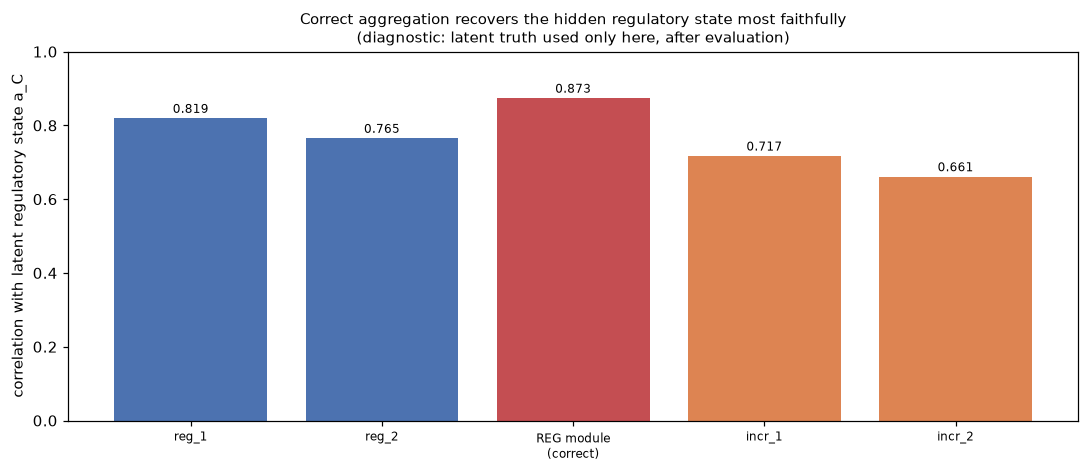

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.4))
labels_ = ["reg_1", "reg_2", "REG module\n(correct)", "incr_1", "incr_2"]
vals = [r(candidates["reg_feature_1"], a_C), r(candidates["reg_feature_2"], a_C),
        r(correct_scores[:, 0], a_C), r(incorrect_scores[:, 0], a_C), r(incorrect_scores[:, 1], a_C)]
bar_cols = ["#4C72B0", "#4C72B0", "#C44E52", "#DD8452", "#DD8452"]
ax.bar(range(5), vals, color=bar_cols)
ax.set_xticks(range(5)); ax.set_xticklabels(labels_, fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel("correlation with latent regulatory state a_C")
ax.set_title("Correct aggregation recovers the hidden regulatory state most faithfully\n"
             "(diagnostic: latent truth used only here, after evaluation)", fontsize=10)
for i, v in enumerate(vals):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=8)
plt.show()

### The correct grouping recovers the hidden state best — and predicts worst

| quantity | correlation with its true module state |
|---|---|
| `reg_feature_2` | +0.765 |
| `reg_feature_1` | +0.819 |
| **`regulatory_module_score` (correct)** | **+0.873** |
| `incorrect_module_1_score` | +0.717 |
| `incorrect_module_2_score` | +0.661 |

and symmetrically for the pathway module: proxies +0.838 and +0.775, correct score **+0.887**,
incorrect scores +0.722 and +0.692.

**So the aggregation does exactly what the biology says it should.** Averaging two noisy proxies of
one state recovers that state more faithfully than either proxy alone (+0.873 vs +0.819), and the
incorrect grouping — which averages proxies of two *different* states — recovers it less faithfully
than any individual proxy.

**And yet the incorrect grouping predicts better.** That is a genuine dissociation, and it is the
central finding of this task:

> The correct grouping is better at recovering the hidden biological structure and worse at
> predicting the label.

The explanation available from these measurements is in Section 4: the label is a sum over several
latent contributions, and recovering one module state exactly is worth less to a model than keeping
the extra independent direction that correct aggregation deletes. The incorrect grouping is a blur,
but a blur the model can partly invert, whereas the correct grouping throws away a direction
permanently.

Note also that `incorrect_module_1_score` correlates +0.722 with `a_C` **and** +0.72-ish with `a_B` —
it is a mixed quantity by construction, and the diagnostics confirm the mixture rather than
assuming it.

## 8. Summary

### What worked as designed

- **The knowledge graph is the single authoritative source** of membership, with runtime assertions that the control stays complexity-matched (same module count, same sizes, same four columns replaced) and genuinely differs from the correct grouping.
- **Replacement forced a real test.** Appending would have let the model ignore the scores; the secondary diagnostic confirms it would have (LR3a reproduces LR0 to −0.0000 AUROC).
- **Identical folds** (`9b587aa3d19a36f7`), scaling refit per fold, module scores label-free and per-row, nothing tuned, no regrouping after seeing results.
- **The interpretability claim is clean and holds.** Each correct module score separates the classes more than either of its members, and the two module scores take the top two coefficients in LR3 (+0.701, +0.624).
- **The diagnostic confirmed the prior works as biology.** Correct aggregation recovers the hidden module state more faithfully than any alternative (+0.873 vs +0.819 for regulatory, +0.887 vs +0.838 for pathway).

### Negative and unexpected findings

1. **Correct module aggregation does not improve prediction.** LR3 − LR0 AUROC **−0.0033** (1/5 folds), P3 − P0 **−0.0031** (1/5 folds). Both move consistently the wrong way on the headline metric, though accuracy and F1 improve slightly.

2. **The biologically correct grouping is WORSE than the deliberately incorrect one.** LR3 − LR3c = **−0.0054** (1/5 folds), P3 − P3c = −0.0006. A wrong grouping beating the right one, in 4 of 5 folds, by roughly the size of the entire effect, is the sharpest negative result in this project.

3. **The diagnostic dissociation is the real finding.** Correct aggregation recovers the hidden module state *better* than any alternative while predicting *worse*. Recovering biological structure and predicting the label come apart here.

4. **Brier degrades most under module replacement** — P3 − P0 = **+0.0070**, the largest single calibration degradation anywhere in this project, against +0.0031 AUROC. Prototype margins become less informative when a dimension is replaced by an average of two correlated ones.

5. **The denoising gain was real but tiny.** Univariate correlation with the label rose from +0.387 to +0.391 (regulatory) and +0.402 to +0.407 (pathway). The proxy pairs already share substantial variation (~0.64), so equal-weight averaging provides only limited additional denoising. Whether that shared variation is measurement noise or genuine shared signal is not determinable from these data, so the interpretation stays tentative. Either way the gain was not enough to pay for the deleted direction.

6. **The control changed what the result means.** Without LR3c, the −0.0033 would have been reported as "module aggregation is roughly neutral". With it, the sharper statement is available: **the incorrect-grouping control shows that the predictive loss cannot simply be attributed to averaging or dimensionality reduction alone. In this experiment, the biologically correct grouping did not confer a predictive advantage.** Note what this does *not* establish — it does not show that biological correctness caused the loss, only that the correct grouping did not help while an equally complex wrong grouping did about as well or better.

### The core dissociation, stated plainly

Four findings that together are this task's central result:

1. **The correct module score recovers its latent module state more faithfully than either individual
   proxy** — `regulatory_module_score` r = +0.873 with `a_C` against +0.819 and +0.765 for
   `reg_feature_1` and `reg_feature_2`; `pathway_module_score` r = +0.887 with `a_B` against +0.838
   and +0.775.
2. **Correct aggregation does not improve AUROC** in either model family — LR3 − LR0 = −0.0033,
   P3 − P0 = −0.0031, each positive in only 1 of 5 folds.
3. **The incorrect grouping performs at least as well predictively in this dataset** — LR3c beats LR3
   by 0.0054 AUROC, and P3c is within 0.0006 of P3.
4. **Aggregation removes proxy-specific information** — the `reg_feature_1 − reg_feature_2` direction
   is deleted and unrecoverable, and the univariate association gained by averaging is only about
   +0.004.

Better recovery of the hidden biological structure did not translate into better discrimination here.
That gap between the two is the result.

### Answers to the main questions

| question | answer |
|---|---|
| Does correct aggregation improve LR over LR0? | **No** — −0.0033 AUROC, 1/5 folds |
| Does it improve the prototype over P0? | **No** — −0.0031 AUROC, 1/5 folds, and Brier +0.0070 |
| Does correct grouping beat incorrect grouping? | **No** — −0.0054 (logistic), −0.0006 (prototype) |
| Does the aggregated score recover hidden module activity better? | **Yes** — +0.873 / +0.887, best of all alternatives |
| Predictive, interpretive, both, or neither? | **The clearest observed benefit is representational/interpretive: the correct module scores correlate more strongly with their intended latent module states, while predictive metrics do not improve.** The representation also becomes cleaner to read — 2 module-level coefficients replace 4 proxy-level ones, each separating better than its members. Note the grouping was **supplied** by prior knowledge, not learned by the model; the model did not discover module membership. |
| What is sacrificed? | **The proxy-specific direction.** `reg_feature_1 − reg_feature_2` is deleted and unrecoverable, and it turns out to be worth more to the model than exact recovery of the module state. |

### Implications for later work

- **M3 should be reported as an interpretability result, not a predictive one.** A prior that makes a model easier to read while making it slightly worse at guessing is a real and interesting outcome, and reporting it honestly is more valuable than a favourable curve.
- **The dissociation is the transferable lesson.** Better recovery of latent biological structure did not buy better prediction. Any claim that a knowledge-informed model "works because it captures the biology" needs this kind of check, not just an accuracy number.
- **A prior must be tested against an equally complex wrong prior.** This is now established twice (Task 7's generic nonlinear control, Task 8's incorrect grouping), and it is the strongest methodological result in the project.
- **For the remaining stages:** the interpretability-without-accuracy pattern recurs — M1 (physically sensible, harmful), M2 (small positive, not consistent), M3 (biologically correct, harmful). Prior knowledge in this dataset improves *readability* far more reliably than it improves *discrimination*. The write-up should say that plainly rather than presenting a progressive-improvement narrative the data does not support.
- **Rejection (next task) should be compared across conditions on coverage and accepted-sample accuracy, not on AUROC**, since the discrimination differences between conditions are now consistently small and the Brier/calibration differences are larger.

**No data was regenerated. Latent truth was read only in Section 7, after all evaluation. No FRET prior, structural prior, relevance weighting, or rejection was implemented.**